In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [3]:
df = pd.read_csv('Datasets\cumulative.csv')

df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


**Extracting Data**

In [4]:
print(df.columns.tolist())

['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag']


In [5]:
selected = ['koi_period', 'koi_time0bk',  'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg',  'koi_srad','koi_kepmag','koi_disposition']

In [6]:
data_extracted = df[selected].copy()
data_extracted.head()

,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_kepmag,koi_disposition
0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,15.347,CONFIRMED
1,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,15.347,CONFIRMED
2,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,15.436,FALSE POSITIVE
3,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,15.597,FALSE POSITIVE
4,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,15.509,CONFIRMED


In [7]:
data_extracted = data_extracted[data_extracted['koi_disposition'].isin(['CONFIRMED','FALSE POSITIVE'])]

In [8]:
data_extracted['koi_disposition'] = data_extracted['koi_disposition'].map({'FALSE POSITIVE':0, 'CONFIRMED':1})

In [9]:
data_extracted['koi_disposition'].value_counts()

koi_disposition
0    5023
1    2293
Name: count, dtype: int64

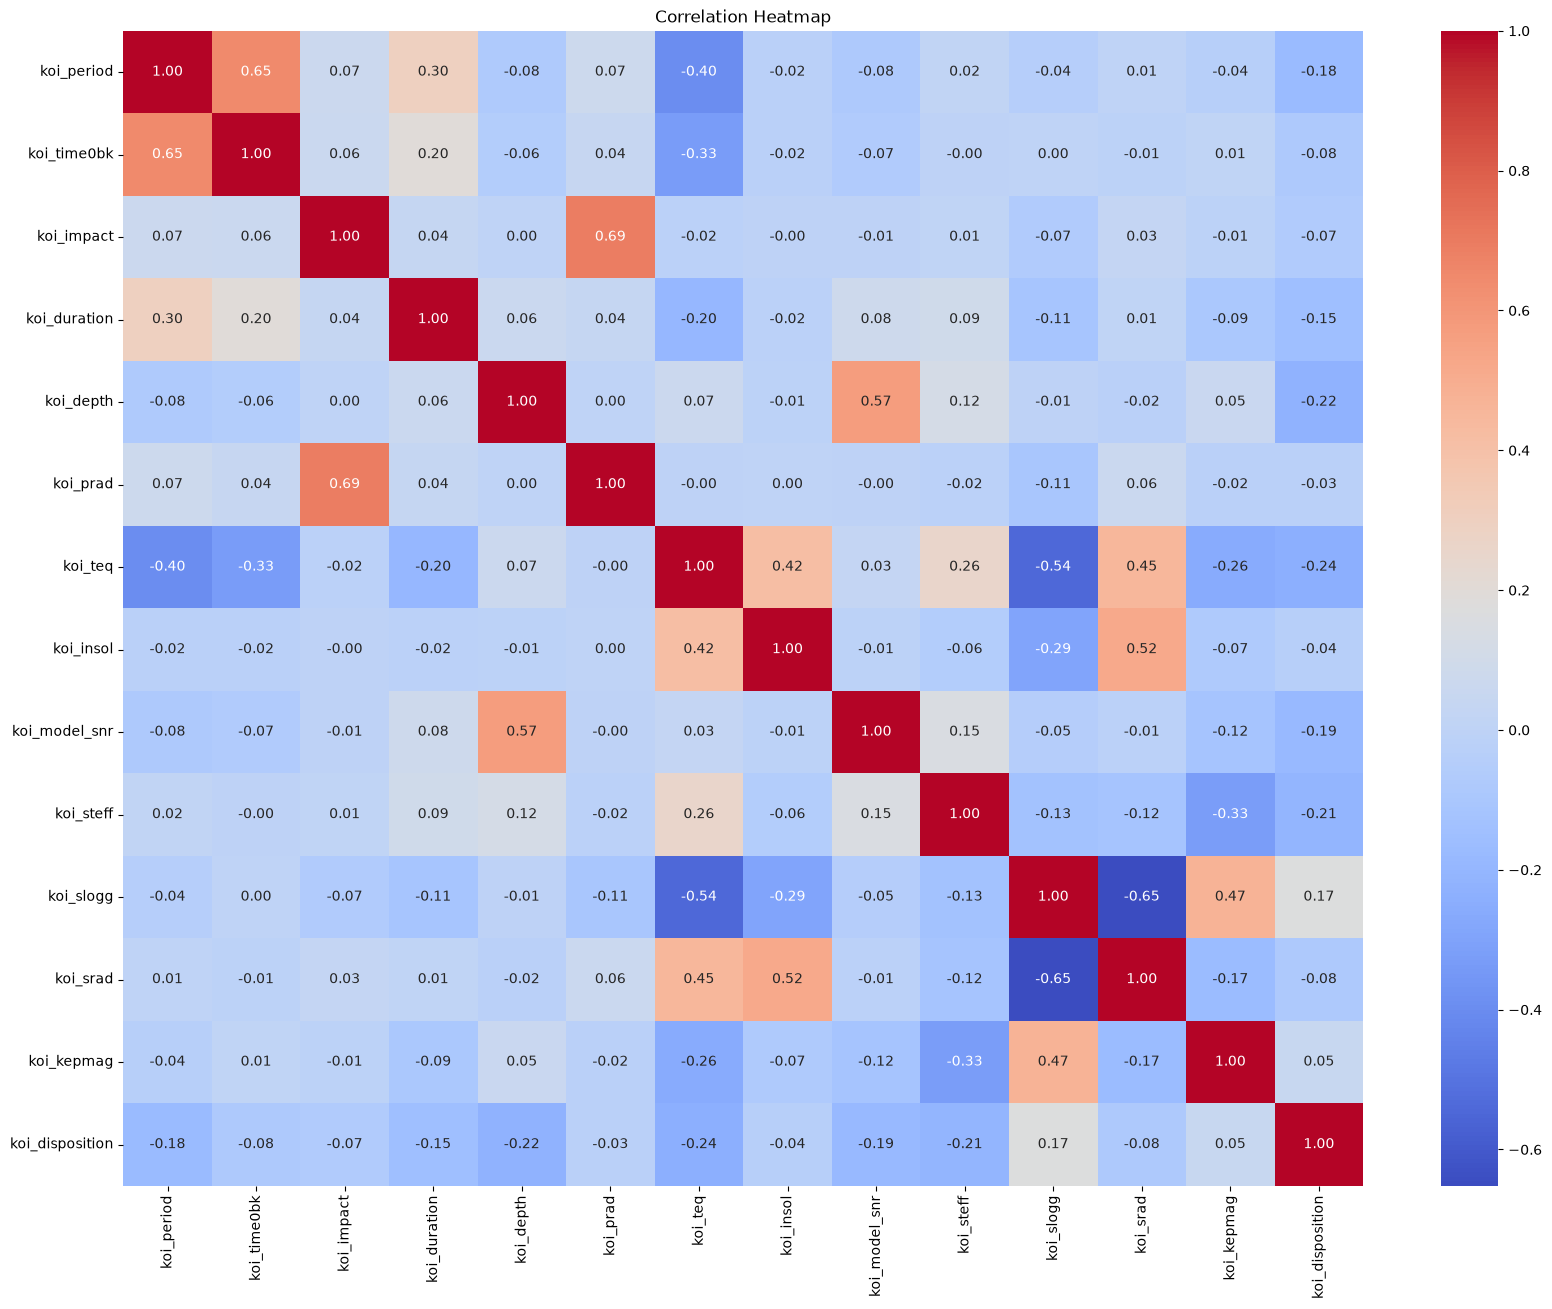

In [10]:
plt.figure(figsize=(20,15))

sns.heatmap(
    data_extracted.corr(numeric_only = True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [11]:
data_extracted.isnull().sum()

koi_period           0
koi_time0bk          0
koi_impact         300
koi_duration         0
koi_depth          300
koi_prad           300
koi_teq            300
koi_insol          259
koi_model_snr      300
koi_steff          300
koi_slogg          300
koi_srad           300
koi_kepmag           1
koi_disposition      0
dtype: int64

In [12]:
data_extracted.dropna(inplace=True)

In [13]:
data_extracted.isnull().sum()

koi_period         0
koi_time0bk        0
koi_impact         0
koi_duration       0
koi_depth          0
koi_prad           0
koi_teq            0
koi_insol          0
koi_model_snr      0
koi_steff          0
koi_slogg          0
koi_srad           0
koi_kepmag         0
koi_disposition    0
dtype: int64

In [16]:
data_extracted['koi_disposition'].value_counts()

koi_disposition
0    4723
1    2292
Name: count, dtype: int64

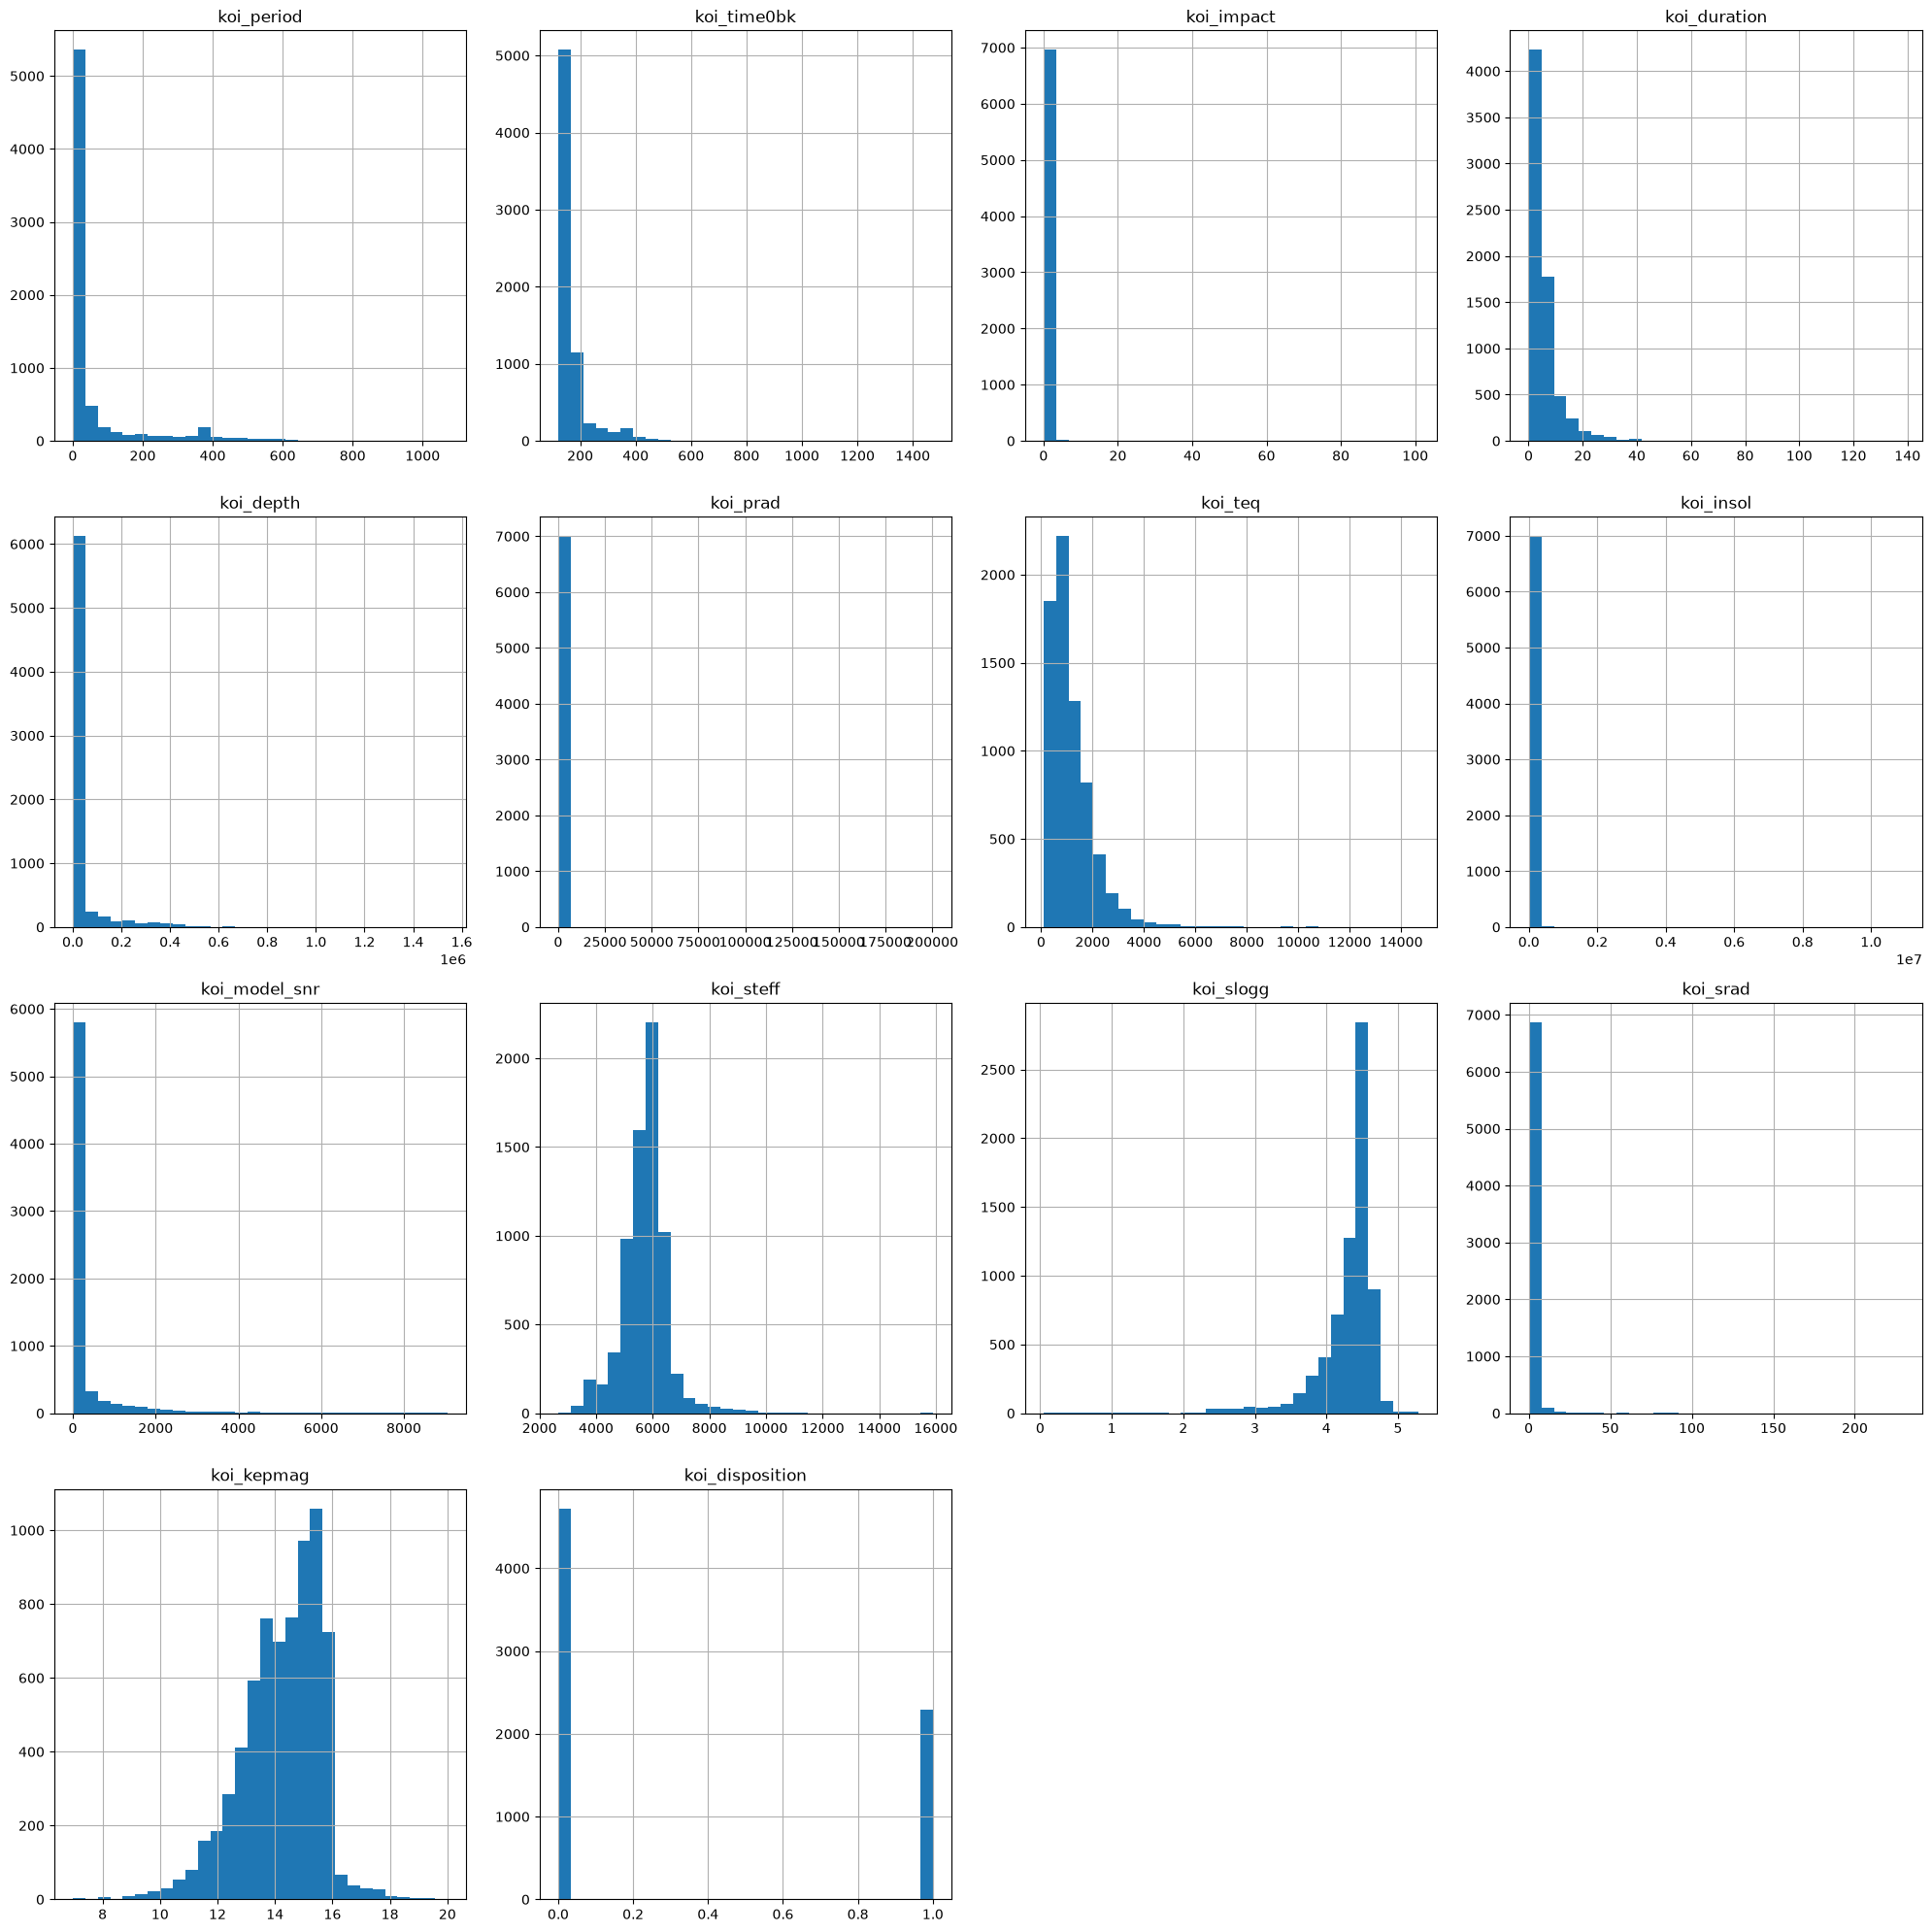

In [14]:
data_extracted.hist(figsize=(20, 20), bins=30)

plt.tight_layout()
plt.show()

In [15]:
data_extracted.to_csv('Datasets\cumulative_cleaned.csv', index=False)